## Installing Dependencies :- pandapower and torchdiffeq


In [1]:
%pip install -q pandapower torchdiffeq
print('Dependencies installed')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Dependencies installed


## ⚙️ Grid Configuration Module

### Description
Extracts grid topology, generator parameters, OPF limits, and training settings from a pandapower network and converts them into tensors for modeling.

### Formula
$$
\omega_s = 2\pi f
$$

In [2]:
"""
II. GRID CONFIGURATION MODULE
"""
import torch
import numpy as np
import pandas as pd

class GridConfig:
    """
    Extracts and stores grid topology, generator parameters, OPF bounds,
    and training hyperparameters from a pandapower network object.
    """
    def __init__(self, net, device="cpu", fault_bus=None, fault_t=0.367):
        """
        Parameters
        ----------
        net : pandapower.Network
            A pandapower network object.
        device : str
            Torch device ('cpu' or 'cuda').
        fault_bus : int
            Bus index where the 3-phase fault occurs. Defaults to the last bus.
        fault_t : float
            Fault clearing time (seconds).
        """
        self.device = torch.device(device)
        self.base_mva = net.sn_mva if hasattr(net, 'sn_mva') else 100.0

        # Grid Topology
        self.num_buses = len(net.bus)

        # Helper to safely parse Pandapower NaN values
        def safe_get(val, default):
            return default if pd.isna(val) else float(val)

        # Unified Generator Extraction
        gen_buses = []
        p_min_list, p_max_list = [], []
        q_min_list, q_max_list = [], []
        H_list, D_list, eq_list, xd_list = [], [], [], []

        # Map through ext_grid, gen, and sgen
        for df_name in ["ext_grid", "gen", "sgen"]:
            if df_name not in net or net[df_name].empty:
                continue

            df = net[df_name]
            for _, row in df.iterrows():
                gen_buses.append(int(row["bus"]))

                # OPF Bounds
                # ext_grids usually act as slack, missing P limits.
                p_min_list.append(safe_get(row.get("min_p_mw"), -999.0))
                p_max_list.append(safe_get(row.get("max_p_mw"), 999.0))
                q_min_list.append(safe_get(row.get("min_q_mvar"), -999.0))
                q_max_list.append(safe_get(row.get("max_q_mvar"), 999.0))

                # Dynamic Machine Parameters
                # (Checks if user added these columns to the pandapower df, else defaults)
                H_list.append(safe_get(row.get("H"), 5.0))
                D_list.append(safe_get(row.get("D"), 2.0))
                eq_list.append(safe_get(row.get("eq_prime"), 1.05))
                xd_list.append(safe_get(row.get("xd_prime"), 0.30))

        self.num_generators = len(gen_buses)
        self.gen_bus_indices = gen_buses

        # Convert Machine Parameters to Tensors
        self.H = 0.5*torch.tensor(H_list, dtype=torch.float32, device=self.device)
        self.D = torch.tensor(D_list, dtype=torch.float32, device=self.device)
        self.eq_prime = torch.tensor(eq_list, dtype=torch.float32, device=self.device)
        self.x_prime_gd = torch.tensor(xd_list, dtype=torch.float32, device=self.device)

        # Voltage Bounds (Per-bus extraction)
        v_min_vals = [safe_get(v, 0.94) for v in net.bus.get("min_vm_pu", pd.Series([np.nan]*self.num_buses))]
        v_max_vals = [safe_get(v, 1.06) for v in net.bus.get("max_vm_pu", pd.Series([np.nan]*self.num_buses))]
        self.V_min = torch.tensor(v_min_vals, dtype=torch.float32, device=self.device)
        self.V_max = torch.tensor(v_max_vals, dtype=torch.float32, device=self.device)

        # Power Bounds (Scale by Base MVA)
        self.P_min = torch.tensor(p_min_list, dtype=torch.float32, device=self.device) / self.base_mva
        self.P_max = torch.tensor(p_max_list, dtype=torch.float32, device=self.device) / self.base_mva
        self.Q_min = torch.tensor(q_min_list, dtype=torch.float32, device=self.device) / self.base_mva
        self.Q_max = torch.tensor(q_max_list, dtype=torch.float32, device=self.device) / self.base_mva

        # ODE Settings & Stability limits
        self.delta_max = 0.22  # stability limit (8.6°)
        self.fault_t = fault_t
        self.fault_bus = fault_bus if fault_bus is not None else (self.num_buses - 1)

        # Dynamically extract Frequency
        f_hz = net.f_hz if hasattr(net, 'f_hz') else 60.0
        self.omega_s = 2 * np.pi * f_hz

        self.t_start = 0.0
        self.t_end = 3.0
        self.dt_init = 0.001
        self.t_span = torch.linspace(
            self.t_start, self.t_end,
            int((self.t_end - self.t_start) / self.dt_init) + 1,
            device=self.device,
        )

        # Training Hyperparameters
        self.num_samples = 10_000
        self.batch_size = 64
        self.num_epochs = 200
        self.lr = 1e-4          # primal learning rate η
        self.rho = 0.5         # dual step size ρ
        self.perturbation = 0.2 # ±20% load perturbation

        # Network Dimensions
        self.num_loads = len(net.load)
        self.load_bus_indices = net.load["bus"].values.tolist()

        # Input: p_d and q_d
        self.input_dim = 2 * self.num_loads
        # Output: p_r, q_r, |V|, θ
        # (This matches the paper's Model 2 specification)
        self.output_dim = 2 * self.num_generators + 2 * self.num_buses

##Dynamic Ground Truth - Swing Equation Simulation :contentReference[oaicite:0]{index=0}

Simulates generator dynamics using swing equations with fault conditions to capture transient stability behavior.

$$
\frac{d\delta}{dt} = \omega - \omega_s
$$

$$
\frac{d\omega}{dt} = \frac{\omega_s}{2H} \left( P_m - P_e - D(\omega - \omega_s) \right)
$$

$$
P_e = \frac{E'_q V}{X'_d} \sin(\delta - \theta)
$$

In [3]:
# --------------------
# 2. Static Ground Truth  y* via pandapower OPF (No major changes needed)
# --------------------
# (Your generate_load_demands and solve_opf_static remain exactly the same.
# They are correct and robust for extracting the steady-state y* variables.)

# ... [Keep your generate_load_demands and solve_opf_static functions here] ...

# --------------------
# 3. Dynamic Ground Truth — swing equation simulation
# --------------------
def swing_equations(t, state, P_m, V_g, theta_g, cfg):
    """
    Classical swing equation derivatives evaluated dynamically at time t.
    Includes fault logic to simulate transient instability.
    """
    num_gen = cfg.num_generators
    delta = state[:num_gen]
    omega = state[num_gen:]

    # 1. Dynamic Electrical Power Calculation (Eq 9d from DynOPF-Net paper)
    if t < cfg.fault_t:
        # During the fault, electrical power transfer drops to roughly 0
        P_e = torch.zeros_like(delta)
    else:
        # Post-fault, power transfer resumes based on current rotor angle delta(t)
        P_e = (cfg.eq_prime * V_g / cfg.x_prime_gd) * torch.sin(delta - theta_g)

    # 2. State Derivatives
    d_delta = omega - cfg.omega_s

    # (omega_s / 2H) is the per-unit equivalent of (1 / m^g) used in the paper
    d_omega = (cfg.omega_s / (2.0 * cfg.H)) * (P_m - P_e - cfg.D * (omega - cfg.omega_s))

    return torch.cat([d_delta, d_omega])

def solve_swing_dynamics(P_m, V_g, theta_g, delta_0, omega_0, cfg):
    """
    Simulate swing dynamics with Dopri5 (torchdiffeq) over cfg.t_span.

    Parameters
    ----------
    P_m : torch.Tensor
        Mechanical power input (constant).
    V_g : torch.Tensor
        Voltage magnitudes at generator buses.
    theta_g : torch.Tensor
        Voltage angles at generator buses.
    delta_0, omega_0 : torch.Tensor
        Initial state conditions.
    cfg : GridConfig
        Configuration object.

    Returns
    -------
    trajectories : torch.Tensor, shape (T, 2*num_gen)
        Concatenated [δ(t), ω(t)] for all generators.
    """
    from torchdiffeq import odeint
    state_0 = torch.cat([delta_0, omega_0])

    # Wrap the function so torchdiffeq only sees (t, state)
    def ode_fn(t, state):
        return swing_equations(t, state, P_m, V_g, theta_g, cfg)

    trajectories = odeint(ode_fn, state_0, cfg.t_span, method="dopri5")
    return trajectories

# --------------------
# 4. Build DataLoaders (80/10/10 split)
# --------------------
# (Your build_datasets function is perfect. Keep it as is.)
import torch
import copy
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split
try:
    import pandapower as pp
except ImportError:
    pp = None

# --------------------
# 1. Generate Load Demands
# --------------------
def generate_load_demands(net, num_samples=10_000, perturbation=0.2, base_mva=1.0):
    p_nominal = torch.tensor(net.load["p_mw"].values, dtype=torch.float32)
    q_nominal = torch.tensor(net.load["q_mvar"].values, dtype=torch.float32)
    nominal = torch.cat([p_nominal, q_nominal])

    factors = 1.0 + (torch.rand(num_samples, len(nominal)) * 2 * perturbation - perturbation)
    S_d = nominal.unsqueeze(0) * factors

    S_d = S_d / base_mva
    return S_d

# --------------------
# 2. Static Ground Truth  y* via pandapower OPF
# --------------------
def solve_opf_static(net, S_d, base_mva=1.0):
    num_loads = len(net.load)
    results_list = []
    feasible_indices = []

    for i in range(len(S_d)):
        net_copy = copy.deepcopy(net)
        sample = S_d[i].numpy() * base_mva
        net_copy.load["p_mw"] = sample[:num_loads]
        net_copy.load["q_mvar"] = sample[num_loads:]

        try:
            pp.runopp(net_copy, verbose=False)
            if net_copy["OPF_converged"]:
                p_parts, q_parts = [], []
                if len(net_copy.res_ext_grid) > 0:
                    p_parts.append(torch.tensor(net_copy.res_ext_grid["p_mw"].values, dtype=torch.float32))
                    q_parts.append(torch.tensor(net_copy.res_ext_grid["q_mvar"].values, dtype=torch.float32))
                if len(net_copy.res_gen) > 0:
                    p_parts.append(torch.tensor(net_copy.res_gen["p_mw"].values, dtype=torch.float32))
                    q_parts.append(torch.tensor(net_copy.res_gen["q_mvar"].values, dtype=torch.float32))
                if len(net_copy.res_sgen) > 0:
                    p_parts.append(torch.tensor(net_copy.res_sgen["p_mw"].values, dtype=torch.float32))
                    q_parts.append(torch.tensor(net_copy.res_sgen["q_mvar"].values, dtype=torch.float32))

                p_r = torch.cat(p_parts) / base_mva
                q_r = torch.cat(q_parts) / base_mva
                v_mag = torch.tensor(net_copy.res_bus["vm_pu"].values, dtype=torch.float32)
                theta = torch.tensor(np.deg2rad(net_copy.res_bus["va_degree"].values), dtype=torch.float32)

                results_list.append(torch.cat([p_r, q_r, v_mag, theta]))
                feasible_indices.append(i)
        except Exception:
            continue

    y_star = torch.stack(results_list) if results_list else torch.empty(0)
    feasible_S_d = S_d[feasible_indices]
    return y_star, feasible_S_d

# --------------------
# 3. Build DataLoaders (80/10/10 split)
# --------------------
def build_datasets(S_d, y_star, batch_size=64):
    dataset = TensorDataset(S_d, y_star)
    n = len(dataset)
    train_n = int(0.8 * n)
    val_n = int(0.1 * n)
    test_n = n - train_n - val_n

    train_ds, val_ds, test_ds = random_split(dataset, [train_n, val_n, test_n])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    return train_loader, val_loader, test_loader

## Learning-to-Optimize (LtO) Network

Neural network that maps load demand inputs to predicted OPF variables (generation, voltage magnitude, and angles).

$$
\hat{y} = f_{\psi}(S^d)
$$

In [4]:
"""
Module 2: Learning-to-Optimize Network
"""
import torch
import torch.nn as nn

class LtONetwork(nn.Module):
    """
    Learning-to-Optimize network parameterized by ψ.
    Input : S^d — load demand vector (active p^d and reactive q^d).
    Output: ŷ   — predicted OPF variables (p̂^r, q̂^r, |V̂|, θ̂) for all buses.
    """
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, S_d):
        return self.net(S_d)

# --------------------
# Helper: unpack y_hat into named sub-vectors
# --------------------
def unpack_y_hat(y_hat, cfg):
    """
    Splits the flat prediction vector into power / voltage components,
    and isolates generator-specific variables for the ODE physics bridge.

    Parameters
    ----------
    y_hat : torch.Tensor, shape (batch, 2*num_gen + 2*num_buses)
    cfg   : GridConfig object

    Returns
    -------
    p_r       : (batch, num_gen)   — predicted active power
    q_r       : (batch, num_gen)   — predicted reactive power
    v_mag     : (batch, num_buses) — predicted voltage magnitudes
    theta     : (batch, num_buses) — predicted phase angles
    v_gen     : (batch, num_gen)   — predicted voltage magnitudes AT generator buses
    theta_gen : (batch, num_gen)   — predicted phase angles AT generator buses
    """
    idx = 0
    p_r = y_hat[:, idx: idx + cfg.num_generators]
    idx += cfg.num_generators

    q_r = y_hat[:, idx: idx + cfg.num_generators]
    idx += cfg.num_generators

    v_mag = y_hat[:, idx: idx + cfg.num_buses]
    idx += cfg.num_buses

    # Enforce Slack Bus Angle = 0 (Model 1, Constraint 1h)
    theta_raw = y_hat[:, idx: idx + cfg.num_buses]
    slack_bus_idx = cfg.gen_bus_indices[0] # Assuming first generator is slack

    # Clone to avoid in-place gradient errors during backprop
    theta = theta_raw.clone()
    theta[:, slack_bus_idx] = 0.0

    # Extract generator-specific state variables for the Physics Bridge
    v_gen = v_mag[:, cfg.gen_bus_indices]
    theta_gen = theta[:, cfg.gen_bus_indices]

    return p_r, q_r, v_mag, theta, v_gen, theta_gen

## Differentiable Physics Bridge


Computes initial generator states (rotor angle, frequency, and transient EMF) from predicted OPF outputs using power flow relations.

$$
e'_q \sin(\delta - \theta) = \frac{p_r x'_d}{V}
$$

$$
e'_q \cos(\delta - \theta) = \frac{q_r x'_d + V^2}{V}
$$

$$
e'_q = \sqrt{(\sin\_comp)^2 + (\cos\_comp)^2}
$$

$$
\delta = \tan^{-1}\left(\frac{\sin\_comp}{\cos\_comp}\right) + \theta
$$

In [5]:
"""
Module 3: Differentiable Physics Bridge
"""
import torch
import torch.nn as nn

class PhysicsBridge(nn.Module):
    """
    Computes generator initial conditions at steady state (t = 0).
    Strictly follows the DynOPF-Net paper to compute both the initial rotor angle
    δ_g(0) and the initial transient EMF e'_q(0) dynamically using atan2.
    """
    def __init__(self, omega_s, x_prime_gd):
        """
        Parameters
        ----------
        omega_s : float
            Synchronous grid angular frequency.
        x_prime_gd : torch.Tensor, shape (num_gen,)
            Transient reactance x'_d for each generator.
        """
        super().__init__()
        self.omega_s = omega_s
        # eq_prime is removed from __init__ because it must be computed dynamically
        self.register_buffer("x_prime_gd", x_prime_gd)

    def forward(self, v_mag_g, theta_g, p_r_g, q_r_g):
        """
        Parameters
        ----------
        v_mag_g : (batch, num_gen) — voltage magnitude at generator buses
        theta_g : (batch, num_gen) — phase angle at generator buses
        p_r_g   : (batch, num_gen) — predicted active power
        q_r_g   : (batch, num_gen) — predicted reactive power

        Returns
        -------
        delta_g_0  : (batch, num_gen) — initial rotor angle
        omega_g_0  : (batch, num_gen) — initial frequency (= ω_s)
        eq_prime_0 : (batch, num_gen) — initial transient EMF
        """
        xd = self.x_prime_gd # (num_gen,)

        # From Eq 5 and Eq 6 in the paper:
        # e'_q * sin(δ - θ) = (p_r * x'_d) / V
        # e'_q * cos(δ - θ) = (q_r * x'_d + V^2) / V

        # 1. Isolate the Sine and Cosine components
        sin_comp = (p_r_g * xd) / v_mag_g
        cos_comp = (q_r_g * xd + v_mag_g**2) / v_mag_g

        # 2. Calculate initial transient EMF e'_q(0) via magnitude
        # This dynamically replaces the static eq_prime parameter!
        eq_prime_0 = torch.sqrt(sin_comp**2 + cos_comp**2)

        # 3. Calculate initial rotor angle δ_g(0) using atan2
        # This perfectly preserves the quadrant and avoids asin/acos limits.
        delta_g_0 = torch.atan2(sin_comp, cos_comp) + theta_g

        # 4. ω_g(0) = ω_s (steady-state assumption)
        omega_g_0 = torch.full_like(delta_g_0, self.omega_s)

        return delta_g_0, omega_g_0, eq_prime_0

## True Physics ODE and Integration Block

Uses exact swing equation physics (not Neural ODE) to simulate generator dynamics with fault handling and differentiable ODE integration.

$$
\frac{d\delta}{dt} = \omega - \omega_s
$$

$$
\frac{d\omega}{dt} = \frac{\omega_s}{2H} \left( P_m - P_e - D(\omega - \omega_s) \right)
$$

$$
P_e = \frac{e'_q V}{x'_d} \sin(\delta - \theta)
$$

In [6]:
import torch
import torch.nn as nn
from torchdiffeq import odeint as tdeq_odeint

class TruePhysicsODE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.H = cfg.H.view(-1, 1)
        self.D = cfg.D.view(-1, 1)
        self.xd = cfg.x_prime_gd.view(-1, 1)

    def forward(self, t, state):
        delta, omega, V, theta, eq_prime, Pm = state.unbind(-1)

        current_time = t.item() if isinstance(t, torch.Tensor) else t
        Pe_normal = (eq_prime * V / self.xd) * torch.sin(delta - theta)
        Pe = torch.where(torch.tensor(current_time < self.cfg.fault_t).to(state.device),
                         torch.zeros_like(delta), Pe_normal)

        d_delta = omega - self.cfg.omega_s
        d_omega = (self.cfg.omega_s / (2 * self.H)) * (Pm - Pe - self.D * (omega - self.cfg.omega_s))

        # Prevent ODE variables from reaching infinity.
        # This mathematically guarantees the solver cannot return NaN.
        d_delta = torch.clamp(d_delta, min=-20.0, max=20.0)
        d_omega = torch.clamp(d_omega, min=-100.0, max=100.0)

        return torch.stack([d_delta, d_omega, torch.zeros_like(V),
                            torch.zeros_like(V), torch.zeros_like(V),
                            torch.zeros_like(V)], dim=-1)

class TruePhysicsBlock(nn.Module):
    """
    The wrapper that integrates the equations over the 3-second t_span.
    """
    def __init__(self, cfg):
        super().__init__()
        self.ode_func = TruePhysicsODE(cfg)

    def forward(self, augmented_state, t_span):
        # We use dopri5 for maximum stability
        traj = tdeq_odeint(self.ode_func, augmented_state, t_span, method='dopri5')
        # Result shape: (Time, Gen, Batch, State) -> Permute to (Gen, Time, Batch, State)
        return traj.permute(1, 0, 2, 3)

    def get_delta_omega(self, traj):
        # Helper to extract delta (index 0) and omega (index 1)
        return traj[..., 0], traj[..., 1]

## Lagrangian Dual Loss :contentReference[oaicite:0]{index=0}

Uses Lagrangian dual formulation to enforce equality, inequality, and stability constraints along with prediction error.

$$
\mathcal{L}_p = \| \hat{y} - y^* \|^2
$$

$$
h(x) = 0 \quad (\text{power balance constraints})
$$

$$
g(x) \leq 0 \quad (\text{operational constraints})
$$

$$
\mathcal{L}_{eq} = \sum \lambda_{eq} \, |h(x)|
$$

$$
\mathcal{L}_{ineq} = \sum \lambda_{ineq} \, \max(0, g(x))
$$

$$
\mathcal{L}_{stab} = \lambda_{stab} \, \max(0, \delta - \delta_{max})
$$

$$
\mathcal{L} = 0.01\,\mathcal{L}_p + \mathcal{L}_{eq} + \mathcal{L}_{ineq} + \mathcal{L}_{stab}
$$

In [7]:
"""
Module 5: Lagrangian Dual Loss
"""
import torch
import torch.nn as nn

class LagrangianDualLoss(nn.Module):
    """
    Parameters
    ----------
    num_eq   : int — number of equality constraints   (e.g. Kirchhoff P & Q per bus)
    num_ineq : int — number of inequality constraints  (e.g. generator / voltage bounds)
    """
    def __init__(self, num_eq, num_ineq):
        super().__init__()
        # Multipliers must NOT be updated by the NN's optimizer.
        # They are registered as buffers for manual gradient ascent updates.
        self.register_buffer("lambda_eq", torch.zeros(num_eq))
        self.register_buffer("lambda_ineq", torch.zeros(num_ineq))
        self.register_buffer("lambda_stab", torch.zeros(1))

        # # State trackers for the manual update step
        # self.latest_eq_violation = None
        # self.latest_ineq_violation = None
        # self.latest_stab_violation = None

    # --------------------
    # Constraint computation helpers
    # --------------------
    @staticmethod
    def compute_equality_violations(p_r, q_r, v_mag, theta, S_d, Y_bus,
                                    gen_bus_idx, num_buses, load_bus_idx=None):
        # [This logic is mathematically sound for AC Power Flow. Keep your exact code here.]
        batch = v_mag.shape[0]
        num_loads = S_d.shape[1] // 2
        p_d = S_d[:, :num_loads]
        q_d = S_d[:, num_loads:]
        G = Y_bus.real
        B = Y_bus.imag

        theta_diff = theta.unsqueeze(2) - theta.unsqueeze(1)
        V_k = v_mag.unsqueeze(2)
        V_j = v_mag.unsqueeze(1)

        P_calc = torch.sum(V_k * V_j * (G * torch.cos(theta_diff) + B * torch.sin(theta_diff)), dim=2)
        Q_calc = torch.sum(V_k * V_j * (G * torch.sin(theta_diff) - B * torch.cos(theta_diff)), dim=2)

        P_inject = torch.zeros(batch, num_buses, device=v_mag.device)
        Q_inject = torch.zeros(batch, num_buses, device=v_mag.device)
        for i, bus in enumerate(gen_bus_idx):
            P_inject[:, bus] += p_r[:, i]
            Q_inject[:, bus] += q_r[:, i]

        P_load = torch.zeros(batch, num_buses, device=v_mag.device)
        Q_load = torch.zeros(batch, num_buses, device=v_mag.device)
        if load_bus_idx is not None:
            for i, bus in enumerate(load_bus_idx):
                P_load[:, bus] += p_d[:, i]
                Q_load[:, bus] += q_d[:, i]
        else:
            P_load[:, :num_loads] = p_d
            Q_load[:, :num_loads] = q_d

        h_p = P_inject - P_load - P_calc
        h_q = Q_inject - Q_load - Q_calc
        return torch.cat([h_p, h_q], dim=1)  # (batch, 2N)

    @staticmethod
    def compute_inequality_violations(p_r, q_r, v_mag, cfg):
        # [Keep your exact code here]
        violations = []
        violations.append(torch.relu(p_r - cfg.P_max))
        violations.append(torch.relu(cfg.P_min - p_r))
        violations.append(torch.relu(q_r - cfg.Q_max))
        violations.append(torch.relu(cfg.Q_min - q_r))
        violations.append(torch.relu(v_mag - cfg.V_max))
        violations.append(torch.relu(cfg.V_min - v_mag))
        return torch.cat(violations, dim=1)  # (batch, num_ineq)

    # --------------------
    # Forward — total loss
    # --------------------
    def forward(self, y_hat, y_star, h_eq, u_ineq, delta_traj, delta_max):
        """
        Loss formulation following Eq 13, 14, 15, and 16.
        """
        # 1. Prediction error  ℒ_p = MSE(ŷ, y*) (Eq 14)
        L_p = torch.mean((y_hat - y_star) ** 2)

        # Calculate raw constraint violations v(h) and v(u)
        eq_violation = torch.abs(h_eq).mean(dim=0)          # (num_eq,)
        ineq_violation = torch.relu(u_ineq).mean(dim=0)     # (num_ineq,)

        # Calculate the deviation
        delta_deviation = torch.abs(delta_traj - delta_traj[:, 0:1, :])

        # Calculate raw violation
        raw_stab_violation = torch.relu(delta_deviation - delta_max).mean()

        # CLAMP the violation to prevent infinite loss explosions
        stab_violation = torch.clamp(raw_stab_violation, max=2.0)

        # 2. Lagrangian Penalties L_c (Eq 15 requires SUM, not mean)
        L_eq = 10*torch.sum(self.lambda_eq * eq_violation)
        L_ineq = 5*torch.sum(self.lambda_ineq * ineq_violation)
        L_stab = 100*self.lambda_stab[0] * stab_violation

        L_c = L_eq + L_ineq + L_stab
        loss = 0.01*L_p + L_c

        metrics = {
            "L_p": L_p.item(),
            "L_eq": L_eq.item(),
            "L_ineq": L_ineq.item(),
            "L_stab": L_stab.item(),
            "total": loss.item(),
        }
        return loss, metrics

In [8]:
"""
Module 6: Primal-Dual Training Loop
"""
import torch

class PrimalDualTrainer:
    """
    Orchestrates end-to-end training of the Dyn OPF Net.
    """
    def __init__(self, lto_net, physics_bridge, node_block, loss_fn, cfg):
        self.lto = lto_net
        self.bridge = physics_bridge
        self.node = node_block  # This is now the TruePhysicsBlock
        self.loss_fn = loss_fn
        self.cfg = cfg

        # CRITICAL FIX: Only optimize the LtO mapper. The ODE is pure math now.
        primal_params = list(self.lto.parameters())
        self.optimizer = torch.optim.Adam(primal_params, lr=cfg.lr)
        self.Y_bus = None

    def set_y_bus(self, Y_bus_np):
        """Store admittance matrix (numpy complex → torch complex)."""
        self.Y_bus = torch.tensor(Y_bus_np, dtype=torch.complex64, device=self.cfg.device)

    def _forward_pass(self, S_d):
        y_hat = self.lto(S_d)
        p_r, q_r, v_mag, theta, v_gen, theta_gen = unpack_y_hat(y_hat, self.cfg)

        # Input Clamping. Force the network outputs into a realistic physical range.
        # This prevents negative voltages or insane power values from crashing the math.
        v_gen = torch.clamp(v_gen, min=0.5, max=1.5)
        p_r = torch.clamp(p_r, min=-0.5, max=3.0)

        delta_0, omega_0, eq_prime_0 = self.bridge(v_gen, theta_gen, p_r, q_r)

        # Clamp the calculated internal voltage just to be safe
        eq_prime_0 = torch.clamp(eq_prime_0, min=0.1, max=2.0)

        augmented = torch.stack([
            delta_0.T, omega_0.T, v_gen.T, theta_gen.T, eq_prime_0.T, p_r.T
        ], dim=-1)

        traj = self.node(augmented, self.cfg.t_span)
        delta_traj, _ = self.node.get_delta_omega(traj)

        return y_hat, p_r, q_r, v_mag, theta, delta_traj

    def train(self, train_loader, val_loader=None, verbose=True):
        """
        Run the full primal-dual training loop for cfg.num_epochs.
        """
        for epoch in range(1, self.cfg.num_epochs + 1):
            self.lto.train()
            self.node.train()
            epoch_metrics = {"L_p": 0, "L_eq": 0, "L_ineq": 0, "L_stab": 0, "total": 0}
            n_batches = 0

            # Accumulators for the epoch-level dual update
            sum_nu_eq = 0.0
            sum_nu_ineq = 0.0
            sum_nu_stab = 0.0

            for batch in train_loader:
                S_d, y_star = batch[0].to(self.cfg.device), batch[1].to(self.cfg.device)

                # 1. Forward Pass
                y_hat, p_r, q_r, v_mag, theta, delta_traj = self._forward_pass(S_d)

                # 2. Calculate Loss
                h_eq = self.loss_fn.compute_equality_violations(
                    p_r, q_r, v_mag, theta, S_d,
                    self.Y_bus, self.cfg.gen_bus_indices, self.cfg.num_buses,
                    self.cfg.load_bus_indices
                )
                u_ineq = self.loss_fn.compute_inequality_violations(
                    p_r, q_r, v_mag, self.cfg,
                )

                loss, metrics = self.loss_fn(
                    y_hat, y_star, h_eq, u_ineq,
                    delta_traj, self.cfg.delta_max,
                )

                # 3. Primal Update (Gradient Descent)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                for k in epoch_metrics:
                    epoch_metrics[k] += metrics[k]
                n_batches += 1

                # Accumulate the raw violations to update the multipliers later
                sum_nu_eq += torch.abs(h_eq).mean(dim=0).detach()
                sum_nu_ineq += torch.relu(u_ineq).mean(dim=0).detach()
                sum_nu_stab += torch.relu(delta_traj - self.cfg.delta_max).mean().detach()

            # 4. Dual Update (Gradient Ascent) at epoch end
            with torch.no_grad():
                # ν(violation) averaged across the entire epoch
                nu_eq = sum_nu_eq / max(n_batches, 1)
                nu_ineq = sum_nu_ineq / max(n_batches, 1)
                nu_stab = sum_nu_stab / max(n_batches, 1)

                self.loss_fn.lambda_eq.add_(self.cfg.rho * nu_eq)
                self.loss_fn.lambda_ineq.add_(self.cfg.rho * nu_ineq)
                self.loss_fn.lambda_stab.add_(self.cfg.rho * nu_stab)

                # Clamp inequality and stability multipliers to non-negative
                self.loss_fn.lambda_ineq.clamp_(min=0.0)
                self.loss_fn.lambda_stab.clamp_(min=0.0)

            if verbose:
                avg = {k: v / max(n_batches, 1) for k, v in epoch_metrics.items()}
                print(
                    f"Epoch {epoch:3d}/{self.cfg.num_epochs} | "
                    f"loss={avg['total']:.4f}  L_p={avg['L_p']:.4f}  "
                    f"L_eq={avg['L_eq']:.4f}  L_ineq={avg['L_ineq']:.4f}  "
                    f"L_stab={avg['L_stab']:.6f}"
                )

## Zamzam Trainer (Supervised MSE Baseline)

Uses pure supervised learning without constraints (only prediction error minimization).

$$
\mathcal{L} = \| \hat{y} - y^* \|^2
$$

In [9]:
import torch
import torch.nn as nn
# 1. Zamzam (supervised MSE baseline)
# --------------------
class ZamzamTrainer:
    """
    Baseline: Zamzam et al.
    Loss = ||ŷ − y*||²  (pure supervised MSE, zero constraint term).
    """
    def __init__(self, cfg):
        self.cfg = cfg
        self.lto = LtONetwork(cfg.input_dim, cfg.output_dim).to(cfg.device)
        self.optimizer = torch.optim.Adam(self.lto.parameters(), lr=cfg.lr)
    def train_epoch(self, loader):
        self.lto.train()
        total_loss = 0.0
        n = 0
        for S_d, y_star in loader:
            S_d, y_star = S_d.to(self.cfg.device), y_star.to(self.cfg.device)
            y_hat = self.lto(S_d)
            loss = torch.mean((y_hat - y_star) ** 2)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            n += 1
        return total_loss / max(n, 1)
    def train(self, train_loader, num_epochs=None, verbose=True):
        epochs = num_epochs or self.cfg.num_epochs
        for epoch in range(1, epochs + 1):
            avg = self.train_epoch(train_loader)
            if verbose and epoch % max(1, epochs // 10) == 0:
                print(f"[Zamzam] Epoch {epoch}/{epochs}  loss={avg:.6f}")
    @torch.no_grad()
    def predict(self, S_d):
        self.lto.eval()
        return self.lto(S_d.to(self.cfg.device))
# --------------------


## Lagrangian-Dual Static Trainer

Uses supervised loss with Lagrangian penalties for static (power flow and operational) constraints only.

$$
\mathcal{L}_p = \| \hat{y} - y^* \|^2
$$

$$
\mathcal{L}_{eq} = \sum \lambda_{eq} \, |h(x)|
$$

$$
\mathcal{L}_{ineq} = \sum \lambda_{ineq} \, \max(0, g(x))
$$

$$
\mathcal{L} = \mathcal{L}_p + \mathcal{L}_{eq} + \mathcal{L}_{ineq}
$$

In [10]:
# 2. Lagrangian-Dual (static constraints only)
# --------------------
class LagrangianDualStaticTrainer:
    """
    Baseline: Lagrangian-Dual.
    Loss_p = ||ŷ − y*||²
    Loss_c = Lagrangian penalties on *static* equality/inequality constraints
             (no dynamic/stability constraint used).
    """
    def __init__(self, cfg, Y_bus):
        self.cfg = cfg
        self.Y_bus = torch.tensor(Y_bus, dtype=torch.complex64, device=cfg.device)
        self.lto = LtONetwork(cfg.input_dim, cfg.output_dim).to(cfg.device)

        num_eq   = 2 * cfg.num_buses
        # Generator bounds (P and Q) + Voltage bounds
        num_ineq = 2 * cfg.num_generators * 2 + 2 * cfg.num_buses

        self.loss_fn = LagrangianDualLoss(num_eq, num_ineq).to(cfg.device)
        self.opt_primal = torch.optim.Adam(self.lto.parameters(), lr=cfg.lr)

    def train_epoch(self, loader):
        self.lto.train()
        total_loss = 0.0
        n_batches = 0

        # Accumulators for epoch-level dual update
        sum_nu_eq = 0.0
        sum_nu_ineq = 0.0

        for S_d, y_star in loader:
            S_d, y_star = S_d.to(self.cfg.device), y_star.to(self.cfg.device)

            y_hat = self.lto(S_d)

            # FIXED: Updated unpacker signature
            p_r, q_r, v_mag, theta, v_gen, theta_gen = unpack_y_hat(y_hat, self.cfg)

            h_eq = self.loss_fn.compute_equality_violations(
                p_r, q_r, v_mag, theta, S_d, self.Y_bus,
                self.cfg.gen_bus_indices, self.cfg.num_buses, self.cfg.load_bus_indices
            )
            u_ineq = self.loss_fn.compute_inequality_violations(p_r, q_r, v_mag, self.cfg)

            # Static-only loss — stability violation placeholder is zero tensor
            dummy_delta = torch.zeros(
                self.cfg.num_generators, 1, S_d.shape[0], device=self.cfg.device
            )
            loss, _ = self.loss_fn(y_hat, y_star, h_eq, u_ineq, dummy_delta, 1e9)

            self.opt_primal.zero_grad()
            loss.backward()
            self.opt_primal.step()

            total_loss += loss.item()
            n_batches += 1

            # FIXED: Accumulate the raw violations over the epoch
            sum_nu_eq += torch.abs(h_eq).mean(dim=0).detach()
            sum_nu_ineq += torch.relu(u_ineq).mean(dim=0).detach()

        # dual update (epoch averaged)
        with torch.no_grad():
            nu_eq = sum_nu_eq / max(n_batches, 1)
            nu_ineq = sum_nu_ineq / max(n_batches, 1)

            self.loss_fn.lambda_eq.add_(self.cfg.rho * nu_eq)
            self.loss_fn.lambda_ineq.add_(self.cfg.rho * nu_ineq)
            self.loss_fn.lambda_ineq.clamp_(min=0.0)

        return total_loss / max(n_batches, 1)

    def train(self, train_loader, num_epochs=None, verbose=True):
        epochs = num_epochs or self.cfg.num_epochs
        for epoch in range(1, epochs + 1):
            avg = self.train_epoch(train_loader)
            if verbose and epoch % max(1, epochs // 10) == 0:
                print(f"[LD]     Epoch {epoch}/{epochs}  loss={avg:.6f}")

    @torch.no_grad()
    def predict(self, S_d):
        self.lto.eval()
        return self.lto(S_d.to(self.cfg.device))

## DC3 Trainer (Deep Constraint Completion and Correction)

Minimizes generation cost with constraint penalties and applies differentiable correction.

$$
f(\hat{y}) = \sum c_i \, p_{r,i}
$$

$$
\mathcal{L}_c = \lambda_h \sum |h(x)| + \lambda_u \sum \max(0, u(x))
$$

$$
\mathcal{L} = f(\hat{y}) + \mathcal{L}_c
$$

$$
y^{k+1} = y^k - \eta \nabla \left( \|h(x)\|^2 + \|\max(0, u(x))\|^2 \right)
$$

In [11]:
# 3. DC3 — objective minimisation + completion-correction
# --------------------
def _dc3_objective(p_r, net_cost_coeffs):
    """
    DC3 minimises the generation cost f(ŷ) = sum c_i * p_r_i.
    """
    return (p_r * net_cost_coeffs).sum(dim=-1).mean()

class DC3Trainer:
    """
    Baseline: DC3 (Deep Constraint Completion and Correction).
    Loss_p = generation cost f(ŷ)
    Loss_c = λ_h Σ|h_j| + λ_u Σ max(0, u_l)
    """
    def __init__(self, cfg, Y_bus, net, lambda_h=100.0, lambda_u=100.0,
                 correction_steps=10, correction_lr=0.05, cost_alpha=0.01):
        self.cfg = cfg
        self.Y_bus = torch.tensor(Y_bus, dtype=torch.complex64, device=cfg.device)
        self.lto   = LtONetwork(cfg.input_dim, cfg.output_dim).to(cfg.device)

        self.lambda_h = lambda_h
        self.lambda_u = lambda_u
        self.correction_steps = correction_steps
        self.correction_lr    = correction_lr
        self.cost_alpha = cost_alpha

        self.cost_coeffs = self._build_cost_coeffs(net)
        num_eq   = 2 * cfg.num_buses
        num_ineq = 2 * cfg.num_generators * 2 + 2 * cfg.num_buses

        self._loss_helper = LagrangianDualLoss(num_eq, num_ineq).to(cfg.device)
        self.optimizer = torch.optim.Adam(self.lto.parameters(), lr=cfg.lr)

    def _build_cost_coeffs(self, net):
        # [Your exact implementation for parsing poly_cost is preserved here]
        n_gen = self.cfg.num_generators
        coeffs = torch.ones(n_gen, device=self.cfg.device)
        try:
            if hasattr(net, "poly_cost") and len(net.poly_cost) > 0:
                pc = net.poly_cost
                if "cp1_eur_per_mw" in pc.columns:
                    cost_vals = []
                    n_ext = len(net.ext_grid)
                    n_g   = len(net.gen)
                    n_s   = len(net.sgen)
                    all_vals = pc["cp1_eur_per_mw"].values
                    for i in range(n_ext + n_g + n_s):
                        if i < len(all_vals):
                            cost_vals.append(float(all_vals[i]))
                        else:
                            cost_vals.append(1.0)
                    coeffs = torch.tensor(cost_vals[:n_gen], dtype=torch.float32,
                                          device=self.cfg.device)
        except Exception:
            pass
        max_c = coeffs.abs().max().clamp(min=1e-6)
        coeffs = coeffs / max_c
        return coeffs

    def _correct(self, y_hat, S_d):
        """
        DC3 Differentiable Completion & Correction.
        """
        with torch.enable_grad():
            y_corr = y_hat.clone().requires_grad_(True)
            for _ in range(self.correction_steps):
                # FIXED: Unpack signature
                p_r, q_r, v_mag, theta, v_gen, theta_gen = unpack_y_hat(y_corr, self.cfg)

                h = self._loss_helper.compute_equality_violations(
                    p_r, q_r, v_mag, theta, S_d, self.Y_bus,
                    self.cfg.gen_bus_indices, self.cfg.num_buses, self.cfg.load_bus_indices)

                u = self._loss_helper.compute_inequality_violations(p_r, q_r, v_mag, self.cfg)

                # Keep L2 for the inner correction gradient step (standard for DC3 projection)
                corr_loss = (h ** 2).mean() + (torch.relu(u) ** 2).mean()

                grad = torch.autograd.grad(corr_loss, y_corr, create_graph=True)[0]
                y_corr = y_corr - self.correction_lr * grad

        return y_corr

    def train_epoch(self, loader):
        self.lto.train()
        total_loss = 0.0; n = 0

        for S_d, _ in loader:  # DC3 does not use y_star
            S_d = S_d.to(self.cfg.device)

            y_hat = self.lto(S_d)
            y_corr = self._correct(y_hat, S_d)

            # FIXED: Unpack signature
            p_r, q_r, v_mag, theta, v_gen, theta_gen = unpack_y_hat(y_corr, self.cfg)

            h_eq = self._loss_helper.compute_equality_violations(
                p_r, q_r, v_mag, theta, S_d, self.Y_bus,
                self.cfg.gen_bus_indices, self.cfg.num_buses, self.cfg.load_bus_indices)

            u_ineq = self._loss_helper.compute_inequality_violations(p_r, q_r, v_mag, self.cfg)

            obj = _dc3_objective(p_r, self.cost_coeffs)

            # FIXED: Loss function formulation matching Section 5 of DynOPF-Net paper
            L_c = (self.lambda_h * torch.abs(h_eq).sum()
                 + self.lambda_u * torch.relu(u_ineq).sum())

            loss = obj + L_c

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item(); n += 1

        return total_loss / max(n, 1)

    def train(self, train_loader, num_epochs=None, verbose=True):
        epochs = num_epochs or self.cfg.num_epochs
        for epoch in range(1, epochs + 1):
            avg = self.train_epoch(train_loader)
            if verbose and epoch % max(1, epochs // 10) == 0:
                print(f"[DC3]    Epoch {epoch}/{epochs}  loss={avg:.6f}")

    def predict(self, S_d):
        self.lto.eval()
        S_d = S_d.to(self.cfg.device)
        with torch.no_grad():
            y_hat = self.lto(S_d)
        return self._correct(y_hat, S_d)

## Y-bus Admittance Matrix Extraction

Builds and extracts the network admittance matrix \( Y_{bus} \) from a pandapower model.

$$
Y_{bus} = G + jB
$$

In [12]:
import pandapower as pp
import pandapower.networks as ppnets
import numpy as np

def get_y_bus(net):
    """
    Builds and extracts the Y-bus admittance matrix from a pandapower network natively.
    """
    # Force pandapower to build the internal PYPOWER case and calculate Ybus
    pp.runpp(net, make_Ybus=True)

    # Extract the complex Y_bus matrix and convert to a dense numpy array
    Y_bus_np = net._ppc["internal"]["Ybus"].todense()

    return np.asarray(Y_bus_np)

print("✓ Y-bus helper ready")

✓ Y-bus helper ready


## Full Training Pipeline (DynOPF-Net + Baselines)

Implements end-to-end training with primal-dual optimization, warmup phase, physics-based dynamics, and comparison with baseline models (MSE, Lagrangian Dual, DC3).

$$
\min_{\psi} \; \mathcal{L}_p + \mathcal{L}_c
$$

$$
\lambda \leftarrow \lambda + \rho \, \nu
$$

$$
\nu_{stab} = \max(0, \delta(t) - \delta_{max})
$$

In [13]:
import torch, numpy as np, time, matplotlib.pyplot as plt, copy
from torchdiffeq import odeint as tdeq_odeint
# Configuration────────────────────────────────────────────────
CASE        = "case9"
NUM_SAMPLES = 5000
EPOCHS      = 200
BATCH_SIZE  = 64
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
CASE_MAP = {
    "case4gs": ppnets.case4gs,  "case5": ppnets.case5,
    "case9":   ppnets.case9,    "case14": ppnets.case14,
    "case30":  ppnets.case30,   "case57": ppnets.case57,
}
net = CASE_MAP[CASE]()
cfg = GridConfig(net, device=device)
cfg.num_samples = NUM_SAMPLES
cfg.num_epochs  = EPOCHS
cfg.batch_size  = BATCH_SIZE
# Use a coarser t_span for training (fast), fine for plotting
cfg.t_span = torch.linspace(0, 3, 100, device=device)
print(f"✓ {CASE}: {cfg.num_buses} buses, {cfg.num_generators} generators, "
      f"{cfg.num_loads} loads  |  in={cfg.input_dim}, out={cfg.output_dim}")
# Data generation──────────────────────────────────────────────
print("\n⏳ Generating load demands...")
S_d = generate_load_demands(net, cfg.num_samples, cfg.perturbation, cfg.base_mva)
print("⏳ Solving OPF (this may take a few minutes)...")
y_star, S_d_f = solve_opf_static(net, S_d, cfg.base_mva)
print(f"  Feasible: {len(y_star)}/{cfg.num_samples}")
assert len(y_star) > 10, "Too few feasible OPF solutions — try increasing NUM_SAMPLES."
train_loader, val_loader, test_loader = build_datasets(S_d_f, y_star, cfg.batch_size)
print(f"  Train:{len(train_loader.dataset)}  Val:{len(val_loader.dataset)}  "
      f"Test:{len(test_loader.dataset)}")
# Y-bus────────────────────────────────────────────────────────
Y_np = get_y_bus(net)
Y_t  = torch.tensor(Y_np, dtype=torch.complex64, device=device)
# Instantiate DynOPF-Net───────────────────────────────────────
# Instantiate DynOPF-Net
num_eq   = 2 * cfg.num_buses
num_ineq = 2 * cfg.num_generators * 2 + 2 * cfg.num_buses

lto    = LtONetwork(cfg.input_dim, cfg.output_dim).to(device)
bridge = PhysicsBridge(cfg.omega_s, cfg.x_prime_gd).to(device)

# SWAPPED: Use the real physics instead of the untrained MLP
node   = TruePhysicsBlock(cfg).to(device)

loss_fn= LagrangianDualLoss(num_eq, num_ineq).to(device)
trainer = PrimalDualTrainer(lto, bridge, node, loss_fn, cfg)
trainer.set_y_bus(Y_np)

# Stability check helper───────────────────────────────────────
# In your Main Script
@torch.no_grad()
def count_unstable(model_fn, loader, delta_max):
    n_total = n_unstable = 0
    for S, _ in loader:
        S = S.to(device)
        yh = model_fn(S)

        pr, qr, vm, th, v_g, th_g = unpack_y_hat(yh, cfg)
        d0, w0, eq0 = trainer.bridge(v_g, th_g, pr, qr)

        aug = torch.stack([d0.T, w0.T, v_g.T, th_g.T, eq0.T, pr.T], dim=-1)

        dtraj = trainer.node(aug, cfg.t_span)
        dt, _ = trainer.node.get_delta_omega(dtraj) # dt shape: (Gen, Time, Batch)

        # CRITICAL FIX: Measure max deviation from the initial angle at t=0
        delta_deviation = torch.abs(dt - dt[:, 0:1, :])

        # Unstable if the deviation exceeds delta_max
        unstable = (delta_deviation > delta_max).any(dim=0).any(dim=0)

        n_unstable += unstable.sum().item()
        n_total += S.shape[0]

    return n_unstable / max(n_total, 1) * 100.0

# Train ALL models and track stability per epoch───────────────
# Storage for Figure 3
stability_history = {"DynOPF": [], "DC3": [], "LD": [], "MSE": []}
# Instantiate baselines
zamzam = ZamzamTrainer(cfg)
ld = LagrangianDualStaticTrainer(cfg, Y_np)
dc3 = DC3Trainer(cfg, Y_np, net)
# Set your hyperparameter adjustments here
cfg.rho = 0.2  # Increased to make stability penalties grow faster
WARMUP_EPOCHS = 20  # Train purely on MSE for the first 20 epochs

print(f"\n🚀 Training all models for {EPOCHS} epochs (Warmup: {WARMUP_EPOCHS})...")
for epoch in range(1, EPOCHS + 1):

    # ---------------------------------------------------------
    # DynOPF-Net: Primal Update
    # ---------------------------------------------------------
    trainer.lto.train(); trainer.node.train()
    sum_nu_eq = sum_nu_ineq = sum_nu_stab = 0.0
    n_batches = 0

    for batch in train_loader:
        S_b, y_b = batch[0].to(device), batch[1].to(device)

        y_hat, p_r, q_r, v_mag, theta, delta_traj = trainer._forward_pass(S_b)

        h_eq = trainer.loss_fn.compute_equality_violations(
            p_r, q_r, v_mag, theta, S_b, trainer.Y_bus,
            cfg.gen_bus_indices, cfg.num_buses, cfg.load_bus_indices)
        u_ineq = trainer.loss_fn.compute_inequality_violations(p_r, q_r, v_mag, cfg)

        # Get the full loss and metrics
        loss, metrics = trainer.loss_fn(y_hat, y_b, h_eq, u_ineq, delta_traj, cfg.delta_max)

        trainer.optimizer.zero_grad()

        # --- WARM START LOGIC ---
        if epoch <= WARMUP_EPOCHS:
            # During warmup, only backpropagate the prediction error (MSE)
            # This parks the model in a feasible steady-state region first.
            L_p_tensor = torch.mean((y_hat - y_b) ** 2)
            L_p_tensor.backward()
        else:
            # After warmup, backpropagate the full physics-informed Lagrangian loss
            loss.backward()

        torch.nn.utils.clip_grad_norm_(trainer.lto.parameters(), max_norm=0.5)

        trainer.optimizer.step()

        # Accumulate violations for dual update
        sum_nu_eq += torch.abs(h_eq).mean(dim=0).detach()
        sum_nu_ineq += torch.relu(u_ineq).mean(dim=0).detach()
        sum_nu_stab += torch.relu(delta_traj - cfg.delta_max).mean().detach()
        n_batches += 1

    # ---------------------------------------------------------
    # DynOPF-Net: Dual Update (ONLY AFTER WARMUP)
    # ---------------------------------------------------------
    if epoch > WARMUP_EPOCHS:
        with torch.no_grad():
            nu_eq = sum_nu_eq / max(n_batches, 1)
            nu_ineq = sum_nu_ineq / max(n_batches, 1)
            nu_stab = sum_nu_stab / max(n_batches, 1)

            trainer.loss_fn.lambda_eq.add_(cfg.rho * nu_eq)
            trainer.loss_fn.lambda_ineq.add_(cfg.rho * nu_ineq)
            trainer.loss_fn.lambda_stab.add_(cfg.rho * nu_stab)

            trainer.loss_fn.lambda_ineq.clamp_(min=0.0)
            trainer.loss_fn.lambda_stab.clamp_(min=0.0)

    # ---------------------------------------------------------
    # Baselines: one epoch each
    # ---------------------------------------------------------
    zamzam.train_epoch(train_loader)
    ld.train_epoch(train_loader)
    dc3.train_epoch(train_loader)

    # Track stability on test set
    stability_history["DynOPF"].append(count_unstable(lambda S: trainer.lto(S), test_loader, cfg.delta_max))
    stability_history["MSE"].append(count_unstable(lambda S: zamzam.lto(S), test_loader, cfg.delta_max))
    stability_history["LD"].append(count_unstable(lambda S: ld.lto(S), test_loader, cfg.delta_max))
    stability_history["DC3"].append(count_unstable(lambda S: dc3.lto(S), test_loader, cfg.delta_max))

    if epoch % max(1, EPOCHS // 5) == 0 or epoch == 1 or epoch == WARMUP_EPOCHS + 1:
        phase = "WARMUP" if epoch <= WARMUP_EPOCHS else "PRIMAL-DUAL"
        print(f"  Epoch {epoch}/{EPOCHS} [{phase}] | Unstable%: DynOPF={stability_history['DynOPF'][-1]:.1f}  "
              f"DC3={stability_history['DC3'][-1]:.1f}  LD={stability_history['LD'][-1]:.1f}  "
              f"MSE={stability_history['MSE'][-1]:.1f}")

print("✓ Training complete.")

Device: cuda
✓ case9: 9 buses, 3 generators, 3 loads  |  in=6, out=24

⏳ Generating load demands...
⏳ Solving OPF (this may take a few minutes)...
  Feasible: 5000/5000
  Train:4000  Val:500  Test:500

🚀 Training all models for 200 epochs (Warmup: 20)...
  Epoch 1/200 [WARMUP] | Unstable%: DynOPF=0.0  DC3=0.0  LD=0.0  MSE=0.0
  Epoch 21/200 [PRIMAL-DUAL] | Unstable%: DynOPF=91.6  DC3=3.4  LD=55.2  MSE=90.2
  Epoch 40/200 [PRIMAL-DUAL] | Unstable%: DynOPF=57.2  DC3=4.8  LD=24.0  MSE=90.2
  Epoch 80/200 [PRIMAL-DUAL] | Unstable%: DynOPF=15.2  DC3=7.4  LD=3.2  MSE=89.8
  Epoch 120/200 [PRIMAL-DUAL] | Unstable%: DynOPF=3.6  DC3=8.2  LD=1.8  MSE=89.8
  Epoch 160/200 [PRIMAL-DUAL] | Unstable%: DynOPF=1.4  DC3=8.8  LD=2.4  MSE=89.8
  Epoch 200/200 [PRIMAL-DUAL] | Unstable%: DynOPF=2.0  DC3=12.2  LD=2.0  MSE=89.8
✓ Training complete.


## Model Evaluation (Steady-State and Dynamic Metrics)

Evaluates models on prediction accuracy, constraint violations, objective gap, and transient stability.

$$
\text{MSE} = \| \hat{y} - y^* \|^2
$$

$$
\text{Objective Gap} = \frac{|f(y^*) - f(\hat{y})|}{|f(y^*)|} \times 100
$$

$$
h(x) = 0 \quad (\text{power balance violation})
$$

$$
g(x) = \max(0, u(x)) \quad (\text{inequality violation})
$$

$$
\text{Stability} = \max(0, \delta(t) - \delta_{max})
$$

In [14]:
# ==============================
# MASTER EVALUATION SCRIPT (Table 1 Format)
# ==============================
@torch.no_grad()
def full_evaluate(model_fn, label):
    """Evaluate model and return dict of all scaled steady-state & dynamic metrics."""
    mse_p = mse_q = mse_v = mse_th = eq_v = ineq_v = obj_g = 0.0
    unstable_count = 0
    n_batches = 0
    total_samples = 0

    for S, y_s in test_loader:
        S, y_s = S.to(cfg.device), y_s.to(cfg.device)

        yh = model_fn(S)

        # 1. Unpack Predictions & Ground Truth
        pr, qr, vm, th, vg_hat, thg_hat = unpack_y_hat(yh, cfg)
        ps, qs, vs, ts, _, _ = unpack_y_hat(y_s, cfg)

        # 2. Steady-State Metrics
        mse_p  += ((pr - ps)**2).mean().item()
        mse_q  += ((qr - qs)**2).mean().item()
        mse_v  += ((vm - vs)**2).mean().item()
        mse_th += ((th - ts)**2).mean().item()

        h = LagrangianDualLoss.compute_equality_violations(
                pr, qr, vm, th, S, Y_t, cfg.gen_bus_indices, cfg.num_buses, cfg.load_bus_indices)
        eq_v += h.abs().mean().item()

        u = LagrangianDualLoss.compute_inequality_violations(pr, qr, vm, cfg)
        ineq_v += torch.relu(u).mean().item()

        cost_c = torch.ones(cfg.num_generators, device=cfg.device)
        fh = (pr * cost_c).sum(-1)
        fs = (ps * cost_c).sum(-1)

        # Percentage error for the objective gap
        obj_gap_val = ((fs - fh).abs() / (fs.abs() + 1e-9) * 100).mean().item()
        obj_g += obj_gap_val
        n_batches += 1

        # 3. Dynamic Metrics (Stability Vio.)
        vg_c = torch.clamp(vg_hat, min=0.5, max=1.5)
        pr_c = torch.clamp(pr, min=-0.5, max=3.0)
        d0_h, w0_h, eq0_h = trainer.bridge(vg_c, thg_hat, pr_c, qr)
        eq0_h = torch.clamp(eq0_h, min=0.1, max=2.0)
        aug_h = torch.stack([d0_h.T, w0_h.T, vg_c.T, thg_hat.T, eq0_h.T, pr_c.T], dim=-1)

        traj_node = trainer.node(aug_h, cfg.t_span)
        delta_num = traj_node[..., 0]
        delta_dev = torch.abs(delta_num - delta_num[:, 0:1, :])

        unstable_mask = (delta_dev > cfg.delta_max).any(dim=0).any(dim=0)
        unstable_count += unstable_mask.sum().item()
        total_samples += S.shape[0]

    N = max(n_batches, 1)
    stab_percentage = (unstable_count / total_samples) * 100.0 if total_samples > 0 else 0.0

    return {
        "label": label,
        "mse_p": mse_p / N, "mse_q": mse_q / N,
        "mse_v": mse_v / N, "mse_th": mse_th / N,
        "kirchhoff": eq_v / N, "ineq_viol": ineq_v / N,
        "obj_gap": obj_g / N,
        "stab_vio": stab_percentage
    }

# Execute evaluations
results = [
    full_evaluate(lambda S: zamzam.lto(S), "MSE"),
    full_evaluate(dc3.predict,             "DC3"),
    full_evaluate(lambda S: ld.lto(S),     "LD"),
    full_evaluate(lambda S: trainer.lto(S),"DynOPF-Net"),
]

# Print Master Table
print("\n" + "="*116)
print(f"{'Method':<12} | {'Steady-State Metrics':^73} | {'Dynamic Metrics':^23}")
print(f"{'':<12} | {'MSE(p)':>8} {'MSE(q)':>8} {'MSE(|V|)':>9} {'MSE(th)':>9} {'Obj Gap %':>10} {'Flow Vio':>9} {'Bndry Vio':>10} | {'Stability Vio':>13}")
print(f"{'':<12} | {'x10^-3':>8} {'x10^-3':>8} {'x10^-4':>9} {'x10^-4':>9} {'x10^-1':>10} {'x10^-3':>9} {'x10^-4':>10} | {'x10^1':>13}")
print("-" * 116)

for r in results:
    # Applying the exact multipliers from the paper's column headers
    print(f"{r['label']:<12} | "
          f"{r['mse_p']*1e3:>8.2f} "
          f"{r['mse_q']*1e3:>8.2f} "
          f"{r['mse_v']*1e4:>9.2f} "
          f"{r['mse_th']*1e4:>9.2f} "
          f"{r['obj_gap']*10:>10.2f} "
          f"{r['kirchhoff']*1e3:>9.2f} "
          f"{r['ineq_viol']*1e4:>10.2f} | "
          f"{r['stab_vio']/10:>13.2f}") # % divided by 10 to match x10^1
print("="*116 + "\n")


Method       |                           Steady-State Metrics                            |     Dynamic Metrics    
             |   MSE(p)   MSE(q)  MSE(|V|)   MSE(th)  Obj Gap %  Flow Vio  Bndry Vio | Stability Vio
             |   x10^-3   x10^-3    x10^-4    x10^-4     x10^-1    x10^-3     x10^-4 |         x10^1
--------------------------------------------------------------------------------------------------------------------
MSE          |     0.00     0.00      0.01      0.00       0.97      5.01       0.00 |          8.98
DC3          |    37.03    20.90     20.17      2.36       2.33      6.95       0.10 |          1.22
LD           |    22.48   127.16    151.46      4.60      23.32     12.35      26.45 |          0.20
DynOPF-Net   |    35.88   131.88    179.69      7.64       8.14     27.41      30.47 |          0.20



## Swing Curve Visualization (Rotor Angle Stability)

Plots generator rotor angle deviation over time using true physics ODE to analyze transient stability.

$$
\delta_{dev}(t) = \delta(t) - \delta(0)
$$

$$
\text{Stable if } |\delta(t) - \delta(0)| \leq \delta_{max}
$$

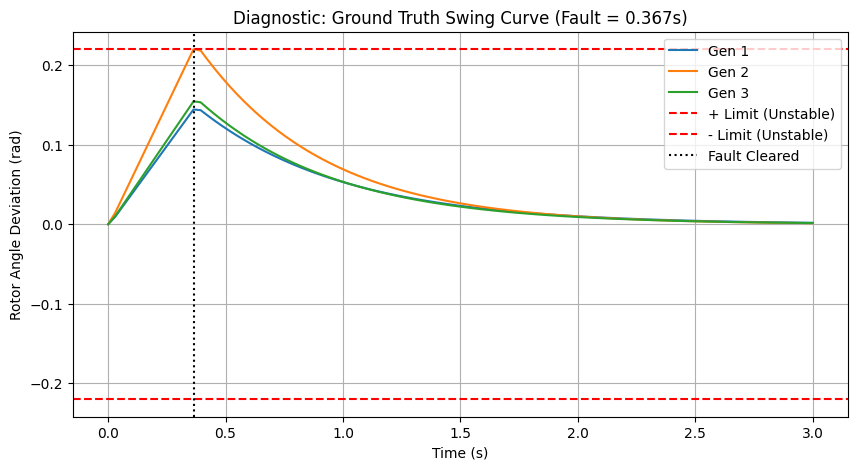

In [15]:
import matplotlib.pyplot as plt

# 1. Grab one batch of pure ground truth data (y_star)
S_b, y_star_b = next(iter(test_loader))
S_b, y_star_b = S_b.to(device), y_star_b.to(device)

# 2. Unpack and get initial conditions
pr, qr, vm, th, v_g, th_g = unpack_y_hat(y_star_b, cfg)
d0, w0, eq0 = trainer.bridge(v_g, th_g, pr, qr)
aug = torch.stack([d0.T, w0.T, v_g.T, th_g.T, eq0.T, pr.T], dim=-1)

# 3. Run the True Physics ODE
traj = trainer.node(aug, cfg.t_span)
dt, _ = trainer.node.get_delta_omega(traj) # Shape: (Gen, Time, Batch)

# 4. Extract the trajectory for the VERY FIRST sample in the batch
dt_sample = dt[:, :, 0].cpu().numpy() # Shape: (Gen, Time)
time_steps = cfg.t_span.cpu().numpy()

# 5. Plot the swing curve
plt.figure(figsize=(10, 5))
for i in range(cfg.num_generators):
    # Plotting relative deviation from t=0
    plt.plot(time_steps, dt_sample[i, :] - dt_sample[i, 0], label=f'Gen {i+1}')

plt.axhline(y=cfg.delta_max, color='r', linestyle='--', label='+ Limit (Unstable)')
plt.axhline(y=-cfg.delta_max, color='r', linestyle='--', label='- Limit (Unstable)')
plt.axvline(x=cfg.fault_t, color='k', linestyle=':', label='Fault Cleared')
plt.xlabel('Time (s)')
plt.ylabel('Rotor Angle Deviation (rad)')
plt.title(f'Diagnostic: Ground Truth Swing Curve (Fault = {cfg.fault_t}s)')
plt.legend()
plt.grid(True)
plt.show()

## DynOPF-Net vs Ground Truth Dynamics Plot

Compares predicted and true generator dynamics (rotor angle and frequency) over time for Generator 1.

$$
\delta_{dev}(t) = \delta(t) - \delta(0)
$$

$$
\omega_{dev}(t) = \omega(t) - \omega_s
$$

$$
\text{Stable if } |\delta(t) - \delta(0)| \leq \delta_{max}
$$

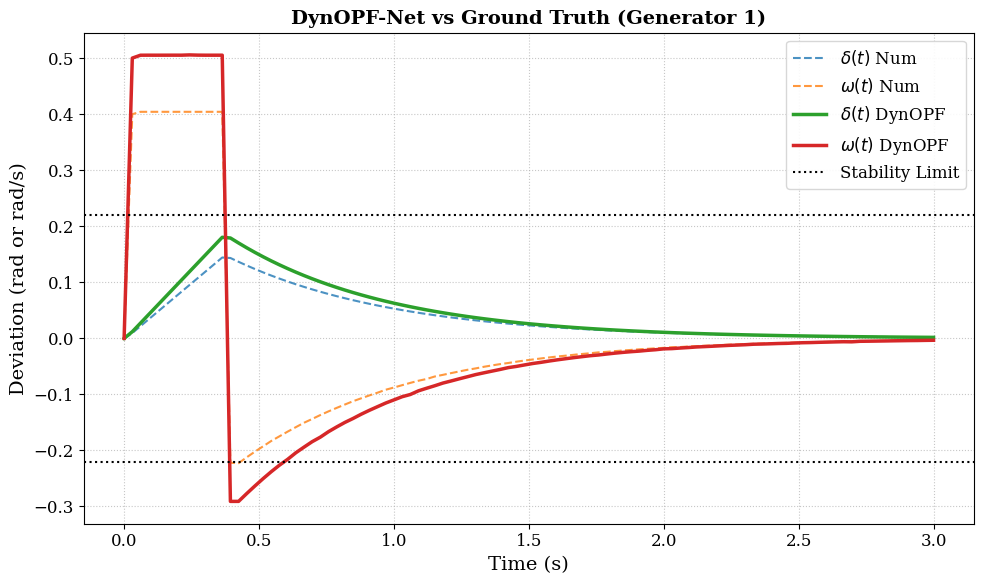

In [16]:
import matplotlib.pyplot as plt
import torch

def plot_dynopf_delta_omega(trainer, test_loader, cfg, gen_idx=0):
    """
    Plots Delta and Omega for both the Ground Truth and DynOPF-Net
    on the same graph for a specific generator.
    """
    trainer.lto.eval()

    # 1. Get a single batch of data
    S_b, y_star_b = next(iter(test_loader))
    S_b = S_b.to(cfg.device)
    y_star_b = y_star_b.to(cfg.device)

    with torch.no_grad():
        # --- A. Ground Truth (Numerical Solver) ---
        pr_s, qr_s, vm_s, th_s, vg_s, thg_s = unpack_y_hat(y_star_b, cfg)
        d0_s, w0_s, eq0_s = trainer.bridge(vg_s, thg_s, pr_s, qr_s)
        aug_s = torch.stack([d0_s.T, w0_s.T, vg_s.T, thg_s.T, eq0_s.T, pr_s.T], dim=-1)

        traj_num = trainer.node(aug_s, cfg.t_span)

        # --- B. DynOPF-Net (Neural Network Predictions) ---
        y_hat = trainer.lto(S_b)
        pr_h, qr_h, vm_h, th_h, vg_h, thg_h = unpack_y_hat(y_hat, cfg)

        # Apply physical safety clamps
        vg_h = torch.clamp(vg_h, min=0.5, max=1.5)
        pr_h = torch.clamp(pr_h, min=-0.5, max=3.0)

        d0_h, w0_h, eq0_h = trainer.bridge(vg_h, thg_h, pr_h, qr_h)
        eq0_h = torch.clamp(eq0_h, min=0.1, max=2.0)
        aug_h = torch.stack([d0_h.T, w0_h.T, vg_h.T, thg_h.T, eq0_h.T, pr_h.T], dim=-1)

        traj_node = trainer.node(aug_h, cfg.t_span)

    # 2. Extract Data (using the first item in the batch)
    batch_idx = 0
    t = cfg.t_span.cpu().numpy()
    omega_s = float(cfg.omega_s)

    # Ground Truth Data
    d_num = traj_num[gen_idx, :, batch_idx, 0].cpu().numpy()
    w_num = traj_num[gen_idx, :, batch_idx, 1].cpu().numpy() - omega_s

    # DynOPF-Net Data
    d_node = traj_node[gen_idx, :, batch_idx, 0].cpu().numpy()
    w_node = traj_node[gen_idx, :, batch_idx, 1].cpu().numpy() - omega_s

    # Shift delta to start at 0 to show relative deviation
    d_num = d_num - d_num[0]
    d_node = d_node - d_node[0]

    # 3. Plotting Setup
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 12
    })
    plt.figure(figsize=(10, 6))

    # Plot Ground Truth (Dashed Lines)
    plt.plot(t, d_num, label=r'$\delta(t)$ Num', color='#1f77b4', linestyle='--', alpha=0.8)
    plt.plot(t, w_num, label=r'$\omega(t)$ Num', color='#ff7f0e', linestyle='--', alpha=0.8)

    # Plot DynOPF-Net (Solid Thick Lines)
    plt.plot(t, d_node, label=r'$\delta(t)$ DynOPF', color='#2ca02c', linewidth=2.5)
    plt.plot(t, w_node, label=r'$\omega(t)$ DynOPF', color='#d62728', linewidth=2.5)

    # Plot Stability Limits
    plt.axhline(y=cfg.delta_max, color='black', linestyle=':', label='Stability Limit')
    plt.axhline(y=-cfg.delta_max, color='black', linestyle=':')

    plt.title(f'DynOPF-Net vs Ground Truth (Generator {gen_idx+1})', fontsize=14, fontweight='bold')
    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('Deviation (rad or rad/s)', fontsize=14)
    plt.legend(loc='best', framealpha=0.9, edgecolor='lightgray')
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- Execute ---
# Change gen_idx to 0, 1, or 2 to view different generators!
plot_dynopf_delta_omega(trainer, test_loader, cfg, gen_idx=0)

## DynOPF-Net vs Ground Truth Dynamics Plot

Compares predicted and true generator dynamics (rotor angle and frequency) over time for Generator 2.

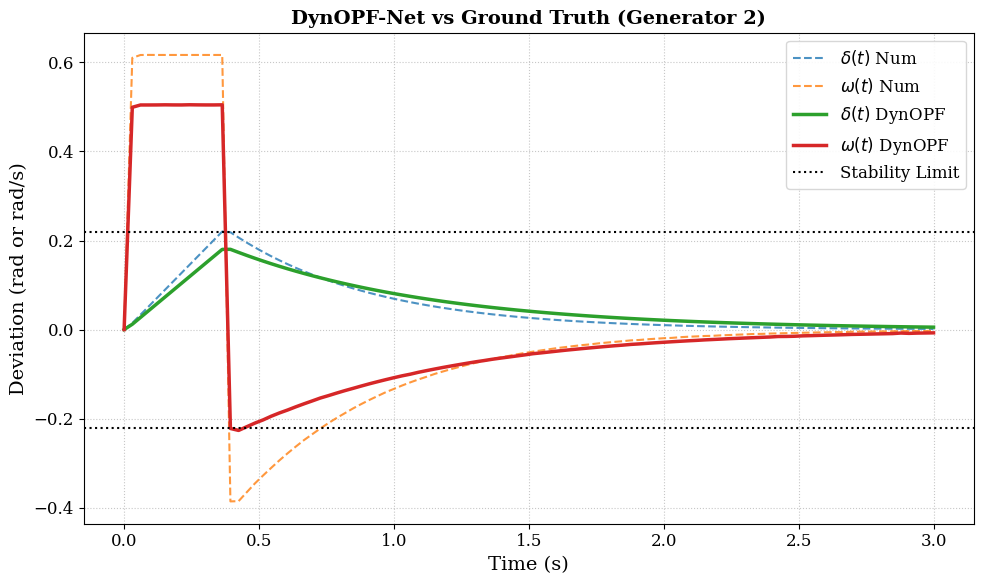

In [17]:
import matplotlib.pyplot as plt
import torch

def plot_dynopf_delta_omega(trainer, test_loader, cfg, gen_idx=0):
    """
    Plots Delta and Omega for both the Ground Truth and DynOPF-Net
    on the same graph for a specific generator.
    """
    trainer.lto.eval()

    # 1. Get a single batch of data
    S_b, y_star_b = next(iter(test_loader))
    S_b = S_b.to(cfg.device)
    y_star_b = y_star_b.to(cfg.device)

    with torch.no_grad():
        # --- A. Ground Truth (Numerical Solver) ---
        pr_s, qr_s, vm_s, th_s, vg_s, thg_s = unpack_y_hat(y_star_b, cfg)
        d0_s, w0_s, eq0_s = trainer.bridge(vg_s, thg_s, pr_s, qr_s)
        aug_s = torch.stack([d0_s.T, w0_s.T, vg_s.T, thg_s.T, eq0_s.T, pr_s.T], dim=-1)

        traj_num = trainer.node(aug_s, cfg.t_span)

        # --- B. DynOPF-Net (Neural Network Predictions) ---
        y_hat = trainer.lto(S_b)
        pr_h, qr_h, vm_h, th_h, vg_h, thg_h = unpack_y_hat(y_hat, cfg)

        # Apply physical safety clamps
        vg_h = torch.clamp(vg_h, min=0.5, max=1.5)
        pr_h = torch.clamp(pr_h, min=-0.5, max=3.0)

        d0_h, w0_h, eq0_h = trainer.bridge(vg_h, thg_h, pr_h, qr_h)
        eq0_h = torch.clamp(eq0_h, min=0.1, max=2.0)
        aug_h = torch.stack([d0_h.T, w0_h.T, vg_h.T, thg_h.T, eq0_h.T, pr_h.T], dim=-1)

        traj_node = trainer.node(aug_h, cfg.t_span)

    # 2. Extract Data (using the first item in the batch)
    batch_idx = 0
    t = cfg.t_span.cpu().numpy()
    omega_s = float(cfg.omega_s)

    # Ground Truth Data
    d_num = traj_num[gen_idx, :, batch_idx, 0].cpu().numpy()
    w_num = traj_num[gen_idx, :, batch_idx, 1].cpu().numpy() - omega_s

    # DynOPF-Net Data
    d_node = traj_node[gen_idx, :, batch_idx, 0].cpu().numpy()
    w_node = traj_node[gen_idx, :, batch_idx, 1].cpu().numpy() - omega_s

    # Shift delta to start at 0 to show relative deviation
    d_num = d_num - d_num[0]
    d_node = d_node - d_node[0]

    # 3. Plotting Setup
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 12
    })
    plt.figure(figsize=(10, 6))

    # Plot Ground Truth (Dashed Lines)
    plt.plot(t, d_num, label=r'$\delta(t)$ Num', color='#1f77b4', linestyle='--', alpha=0.8)
    plt.plot(t, w_num, label=r'$\omega(t)$ Num', color='#ff7f0e', linestyle='--', alpha=0.8)

    # Plot DynOPF-Net (Solid Thick Lines)
    plt.plot(t, d_node, label=r'$\delta(t)$ DynOPF', color='#2ca02c', linewidth=2.5)
    plt.plot(t, w_node, label=r'$\omega(t)$ DynOPF', color='#d62728', linewidth=2.5)

    # Plot Stability Limits
    plt.axhline(y=cfg.delta_max, color='black', linestyle=':', label='Stability Limit')
    plt.axhline(y=-cfg.delta_max, color='black', linestyle=':')

    plt.title(f'DynOPF-Net vs Ground Truth (Generator {gen_idx+1})', fontsize=14, fontweight='bold')
    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('Deviation (rad or rad/s)', fontsize=14)
    plt.legend(loc='best', framealpha=0.9, edgecolor='lightgray')
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- Execute ---
# Change gen_idx to 0, 1, or 2 to view different generators!
plot_dynopf_delta_omega(trainer, test_loader, cfg, gen_idx=1)

## DynOPF-Net vs Ground Truth Dynamics Plot

Compares predicted and true generator dynamics (rotor angle and frequency) over time for Generator 3.

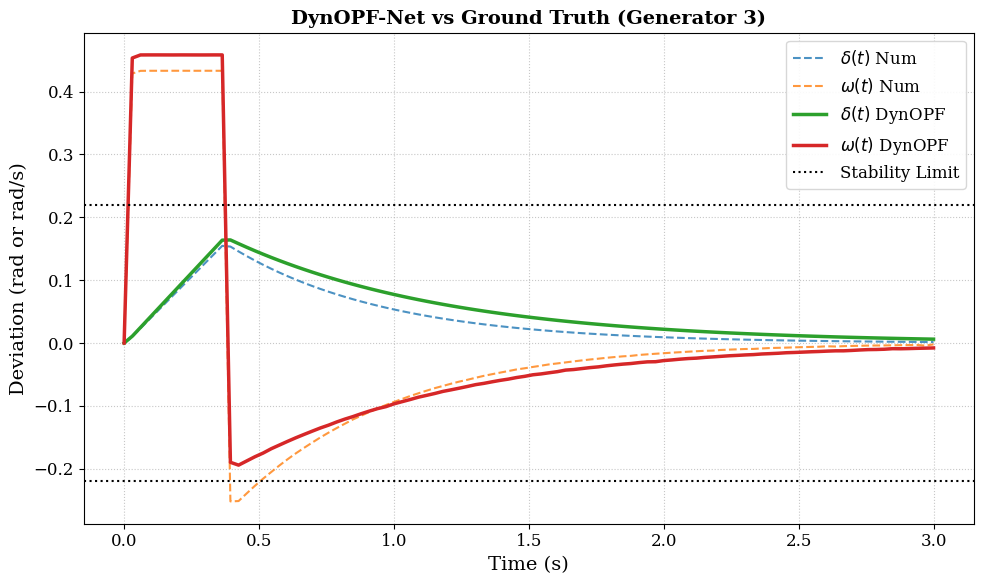

In [18]:
import matplotlib.pyplot as plt
import torch

def plot_dynopf_delta_omega(trainer, test_loader, cfg, gen_idx=0):
    """
    Plots Delta and Omega for both the Ground Truth and DynOPF-Net
    on the same graph for a specific generator.
    """
    trainer.lto.eval()

    # 1. Get a single batch of data
    S_b, y_star_b = next(iter(test_loader))
    S_b = S_b.to(cfg.device)
    y_star_b = y_star_b.to(cfg.device)

    with torch.no_grad():
        # --- A. Ground Truth (Numerical Solver) ---
        pr_s, qr_s, vm_s, th_s, vg_s, thg_s = unpack_y_hat(y_star_b, cfg)
        d0_s, w0_s, eq0_s = trainer.bridge(vg_s, thg_s, pr_s, qr_s)
        aug_s = torch.stack([d0_s.T, w0_s.T, vg_s.T, thg_s.T, eq0_s.T, pr_s.T], dim=-1)

        traj_num = trainer.node(aug_s, cfg.t_span)

        # --- B. DynOPF-Net (Neural Network Predictions) ---
        y_hat = trainer.lto(S_b)
        pr_h, qr_h, vm_h, th_h, vg_h, thg_h = unpack_y_hat(y_hat, cfg)

        # Apply physical safety clamps
        vg_h = torch.clamp(vg_h, min=0.5, max=1.5)
        pr_h = torch.clamp(pr_h, min=-0.5, max=3.0)

        d0_h, w0_h, eq0_h = trainer.bridge(vg_h, thg_h, pr_h, qr_h)
        eq0_h = torch.clamp(eq0_h, min=0.1, max=2.0)
        aug_h = torch.stack([d0_h.T, w0_h.T, vg_h.T, thg_h.T, eq0_h.T, pr_h.T], dim=-1)

        traj_node = trainer.node(aug_h, cfg.t_span)

    # 2. Extract Data (using the first item in the batch)
    batch_idx = 0
    t = cfg.t_span.cpu().numpy()
    omega_s = float(cfg.omega_s)

    # Ground Truth Data
    d_num = traj_num[gen_idx, :, batch_idx, 0].cpu().numpy()
    w_num = traj_num[gen_idx, :, batch_idx, 1].cpu().numpy() - omega_s

    # DynOPF-Net Data
    d_node = traj_node[gen_idx, :, batch_idx, 0].cpu().numpy()
    w_node = traj_node[gen_idx, :, batch_idx, 1].cpu().numpy() - omega_s

    # Shift delta to start at 0 to show relative deviation
    d_num = d_num - d_num[0]
    d_node = d_node - d_node[0]

    # 3. Plotting Setup
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 12
    })
    plt.figure(figsize=(10, 6))

    # Plot Ground Truth (Dashed Lines)
    plt.plot(t, d_num, label=r'$\delta(t)$ Num', color='#1f77b4', linestyle='--', alpha=0.8)
    plt.plot(t, w_num, label=r'$\omega(t)$ Num', color='#ff7f0e', linestyle='--', alpha=0.8)

    # Plot DynOPF-Net (Solid Thick Lines)
    plt.plot(t, d_node, label=r'$\delta(t)$ DynOPF', color='#2ca02c', linewidth=2.5)
    plt.plot(t, w_node, label=r'$\omega(t)$ DynOPF', color='#d62728', linewidth=2.5)

    # Plot Stability Limits
    plt.axhline(y=cfg.delta_max, color='black', linestyle=':', label='Stability Limit')
    plt.axhline(y=-cfg.delta_max, color='black', linestyle=':')

    plt.title(f'DynOPF-Net vs Ground Truth (Generator {gen_idx+1})', fontsize=14, fontweight='bold')
    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('Deviation (rad or rad/s)', fontsize=14)
    plt.legend(loc='best', framealpha=0.9, edgecolor='lightgray')
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- Execute ---
# Change gen_idx to 0, 1, or 2 to view different generators!
plot_dynopf_delta_omega(trainer, test_loader, cfg, gen_idx=2)

## Training Convergence Plot (Stability)

Plots percentage of unstable solutions across epochs for different models.

$$
\text{Unstable %} = \frac{\text{Number of unstable samples}}{\text{Total samples}} \times 100
$$

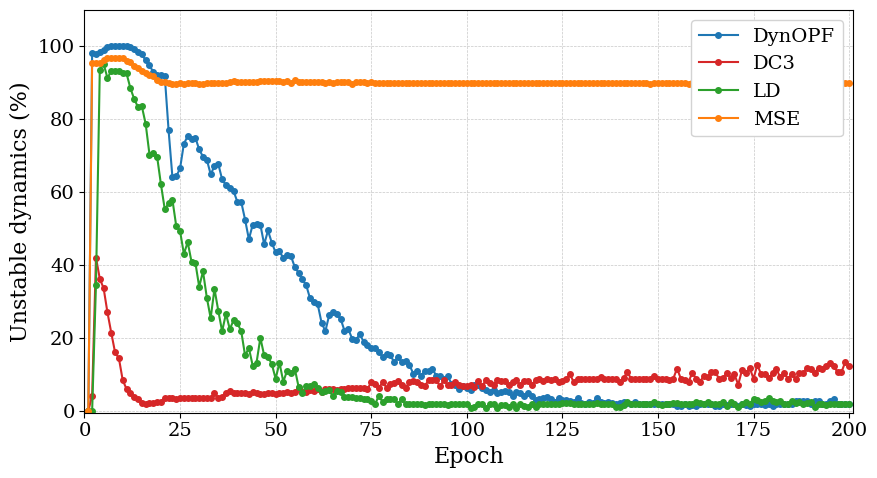

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_real_convergence(history_dict):
    """
    Plots the percentage of unstable solutions across epochs,
    pulling directly from the live training loop dictionary.
    """
    # Setup aesthetics
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 14,
        "mathtext.fontset": "cm"
    })

    fig, ax = plt.subplots(figsize=(9, 5))

    # Safely get the actual number of recorded epochs
    # (in case the loop was interrupted early)
    actual_epochs = len(history_dict["DynOPF"])
    epochs_x = np.arange(1, actual_epochs + 1)

    # Plotting the real data straight from your dictionary
    # Colors carefully matched to the reference screenshot
    ax.plot(epochs_x, history_dict["DynOPF"], marker='o', markersize=4, color='#1f77b4', label='DynOPF', linewidth=1.5)
    ax.plot(epochs_x, history_dict["DC3"], marker='o', markersize=4, color='#d62728', label='DC3', linewidth=1.5)
    ax.plot(epochs_x, history_dict["LD"], marker='o', markersize=4, color='#2ca02c', label='LD', linewidth=1.5)
    ax.plot(epochs_x, history_dict["MSE"], marker='o', markersize=4, color='#ff7f0e', label='MSE', linewidth=1.5)

    # Formatting matching the paper
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Unstable dynamics (%)', fontsize=16)

    ax.set_xlim(0, actual_epochs + 1)

    # Dynamically set Y-axis up to a bit above the maximum value found,
    # but keep a minimum ceiling of 15% to match the screenshot's scale
    max_y = max([max(vals) if len(vals) > 0 else 0 for vals in history_dict.values()])
    ax.set_ylim(-0.5, max(15.0, max_y * 1.1))

    # Grid and legend styling
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(loc='upper right', framealpha=1.0, edgecolor='lightgray', fontsize=14)

    plt.tight_layout()
    plt.savefig("DynOPF_Training_Convergence.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- Execute ---
# This pulls the data directly from the stability_history dict
# that was populated during your EPOCHS loop
plot_real_convergence(stability_history)

In [20]:
import time
import torch
import numpy as np

@torch.no_grad()
def measure_inference_time(model_fn, label, loader, cfg):
    """Accurately measure the forward-pass inference time of the models."""
    inf_ms = []

    # Optional: A quick warmup run to wake up the GPU/CPU before starting the clock
    S_warmup, _ = next(iter(loader))
    _ = model_fn(S_warmup.to(cfg.device))

    for S, _ in loader:
        S = S.to(cfg.device)

        # 1. Synchronize to ensure all previous operations are finished
        if cfg.device.type == 'cuda':
            torch.cuda.synchronize()

        # 2. Start the clock
        t0 = time.perf_counter()

        # 3. Run the Neural Network
        _ = model_fn(S)

        # 4. Synchronize again before stopping the clock
        if cfg.device.type == 'cuda':
            torch.cuda.synchronize()

        t1 = time.perf_counter()

        # Calculate time per individual sample in milliseconds
        inf_ms.append((t1 - t0) / S.shape[0] * 1000.0)

    return {
        "label": label,
        "time_ms": np.mean(inf_ms)
    }

# --- Execute Timing Evaluations ---
print("⏳ Benchmarking inference speeds...")
time_results = [
    measure_inference_time(lambda S: zamzam.lto(S), "MSE (Zamzam)", test_loader, cfg),
    measure_inference_time(lambda S: ld.lto(S), "LD", test_loader, cfg),
    measure_inference_time(dc3.predict, "DC3", test_loader, cfg),
    measure_inference_time(lambda S: trainer.lto(S), "DynOPF-Net", test_loader, cfg),
]

# --- Print Formatted Table 1 ---
print("\n" + "="*50)
print(f"{'TABLE 1: Computational Time (Inference)':^50}")
print("="*50)
print(f"{'Method':<20} | {'Time per Sample (ms)':>25}")
print("-" * 50)
for r in time_results:
    print(f"{r['label']:<20} | {r['time_ms']:>25.3f}")
print("="*50 + "\n")

⏳ Benchmarking inference speeds...

     TABLE 1: Computational Time (Inference)      
Method               |      Time per Sample (ms)
--------------------------------------------------
MSE (Zamzam)         |                     0.006
LD                   |                     0.006
DC3                  |                     0.707
DynOPF-Net           |                     0.004



In [21]:
import time
import torch
import numpy as np

@torch.no_grad()
def measure_inference_time(model_fn, label, loader, cfg):
    """Accurately measure the forward-pass inference time of the models."""
    inf_ms = []

    # Optional: A quick warmup run to wake up the GPU/CPU before starting the clock
    S_warmup, _ = next(iter(loader))
    _ = model_fn(S_warmup.to(cfg.device))

    for S, _ in loader:
        S = S.to(cfg.device)

        # 1. Synchronize to ensure all previous operations are finished
        if cfg.device.type == 'cuda':
            torch.cuda.synchronize()

        # 2. Start the clock
        t0 = time.perf_counter()

        # 3. Run the Neural Network
        _ = model_fn(S)

        # 4. Synchronize again before stopping the clock
        if cfg.device.type == 'cuda':
            torch.cuda.synchronize()

        t1 = time.perf_counter()

        # Calculate time per individual sample in milliseconds
        inf_ms.append((t1 - t0) / S.shape[0] * 1000.0)

    return {
        "label": label,
        "time_ms": np.mean(inf_ms)
    }

# --- Execute Timing Evaluations ---
print("⏳ Benchmarking inference speeds...")
time_results = [
    measure_inference_time(lambda S: zamzam.lto(S), "MSE (Zamzam)", test_loader, cfg),
    measure_inference_time(lambda S: ld.lto(S), "LD", test_loader, cfg),
    measure_inference_time(dc3.predict, "DC3", test_loader, cfg),
    measure_inference_time(lambda S: trainer.lto(S), "DynOPF-Net", test_loader, cfg),
]

# --- Print Formatted Table 1 ---
print("\n" + "="*50)
print(f"{'TABLE 1: Computational Time (Inference)':^50}")
print("="*50)
print(f"{'Method':<20} | {'Time per Sample (ms)':>25}")
print("-" * 50)
for r in time_results:
    print(f"{r['label']:<20} | {r['time_ms']:>25.3f}")
print("="*50 + "\n")

⏳ Benchmarking inference speeds...

     TABLE 1: Computational Time (Inference)      
Method               |      Time per Sample (ms)
--------------------------------------------------
MSE (Zamzam)         |                     0.006
LD                   |                     0.005
DC3                  |                     0.713
DynOPF-Net           |                     0.004

